# *Análisis comparativo masa-resorte-amortiguador*

**`Realizado por:`** Sergio Daniel Martínez Segura.             
**`Materia:`** Dinámica de estructuras.  
**`Pregrado:`** Ingeniería civil.     
**`Institución:`** Universidad Nacional de Colombia.  
**`Docente:`** Juan Pablo Herrera Castaño.  

---  
---  

#### 1. *Se importan los módulos necesarios*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

#### 2. *Condiciones iniciales y parámetros del sistema:*

In [2]:
x0 = 0.1                        # Desplazamiento inicial  [m]
v0 = 5                          # Velocidad inicial       [m/s]

m  = 2750                       # Masa del sistema        [kg]
k  = 1000000                    # rigidez del sistema     [N/m]
wn = np.sqrt(k/m)               # Frecuencia natural      [rad/s]

#### 3. *Se define la función principal de cálculo:* 

Función que permite calcular el desplazamiento, velocidad y aceleración del sistema mediante la solución analítica para un sistema masa-resorte-amortiguador.

In [3]:
def sistema_masa_resorte(xi, t):
    wd = wn*np.sqrt(1 - xi**2)   # Frecuencia natural amortiguada
    
    # Cálculo del desplazamiento
    x = np.exp(-xi*wn*t) * (x0*np.cos(wd*t) + ((v0 + xi*wn*x0)/(wd))*np.sin(wd*t))
    
    # Cálculo de la velocidad (derivada del desplazamiento)
    v = np.exp(-xi*wn*t) * (
        -wn*xi*(x0*np.cos(wd*t) + (v0 + xi*wn*x0)/(wd)*np.sin(wd*t)) +
        wd*(-x0*np.sin(wd*t) + (v0 + xi*wn*x0)/(wd)*np.cos(wd*t))
    )
    
    # Cálculo de la aceleración (derivada de la velocidad)
    a = np.exp(-xi*wn*t) * (
        (wn*xi)**2*(x0*np.cos(wd*t) + (v0 + xi*wn*x0)/(wd)*np.sin(wd*t)) +
        2*wn*xi*wd*(x0*np.sin(wd*t) - (v0 + xi*wn*x0)/(wd)*np.cos(wd*t)) +
        wd**2*(-x0*np.cos(wd*t) - (v0 + xi*wn*x0)/(wd)*np.sin(wd*t))
    )
    
    return x, v, a

#### 4. *Preparación de argumentos y cálculo:*

In [4]:
t = np.linspace(0, 5, 1000)        # Tiempo de simulación
xi_valores = [0.0, 0.05, 0.25]     # Valores de xi a simular

resultados = {}                    # Vamos separando la memoria para guardar los resultados en un diccionario

for xi in xi_valores:
    # Guardamos los tres arrays (x, v, a) en el diccionario como una tupla para cada valor de xi
    resultados[xi] = sistema_masa_resorte(xi, t)

#### 5. *Gráficas de respuesta para cada ξ*

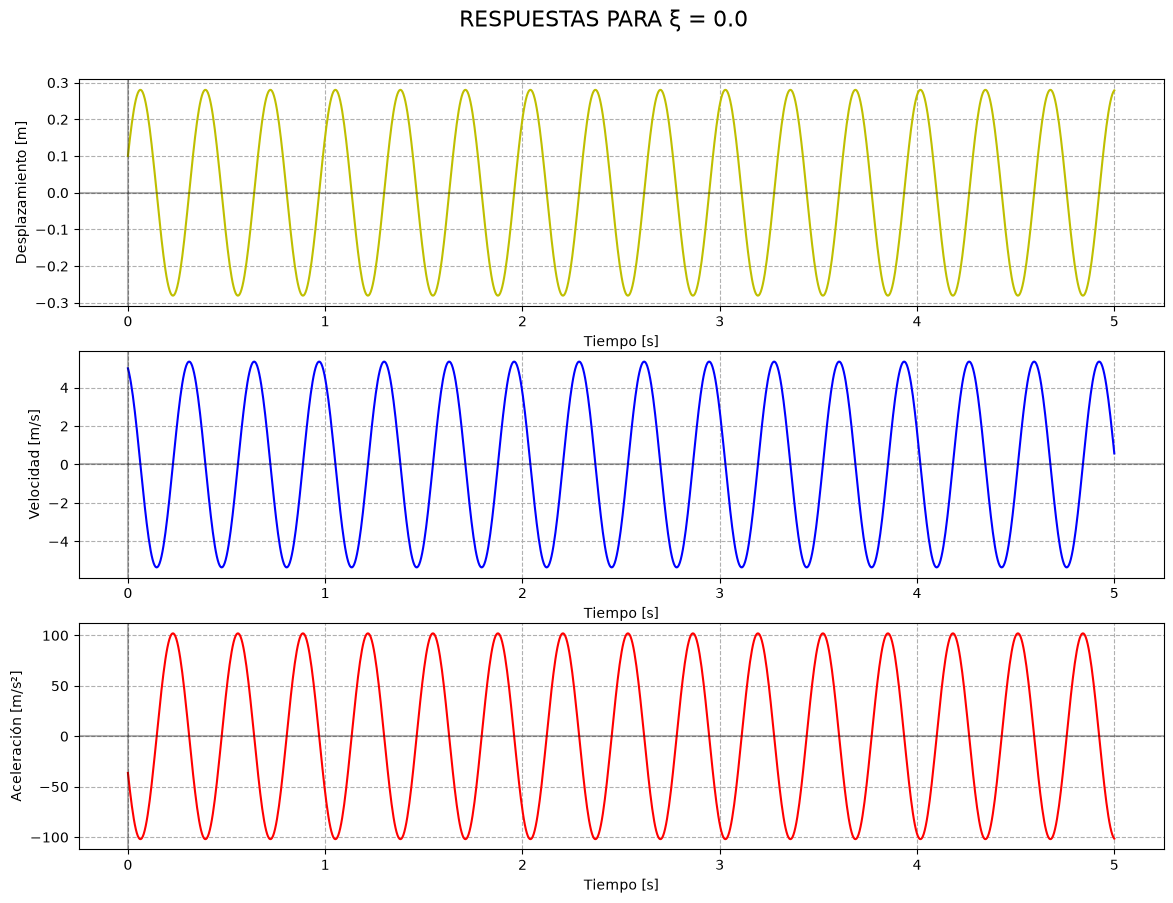

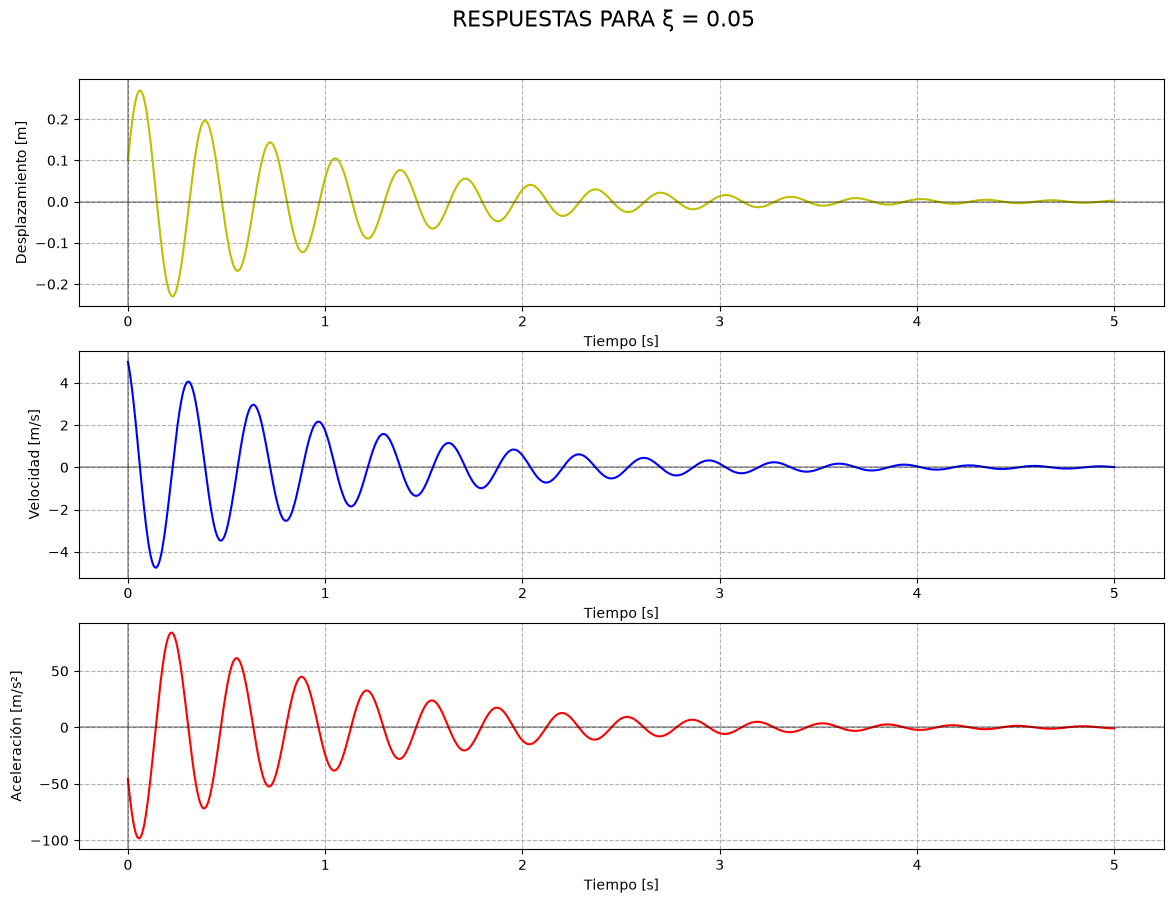

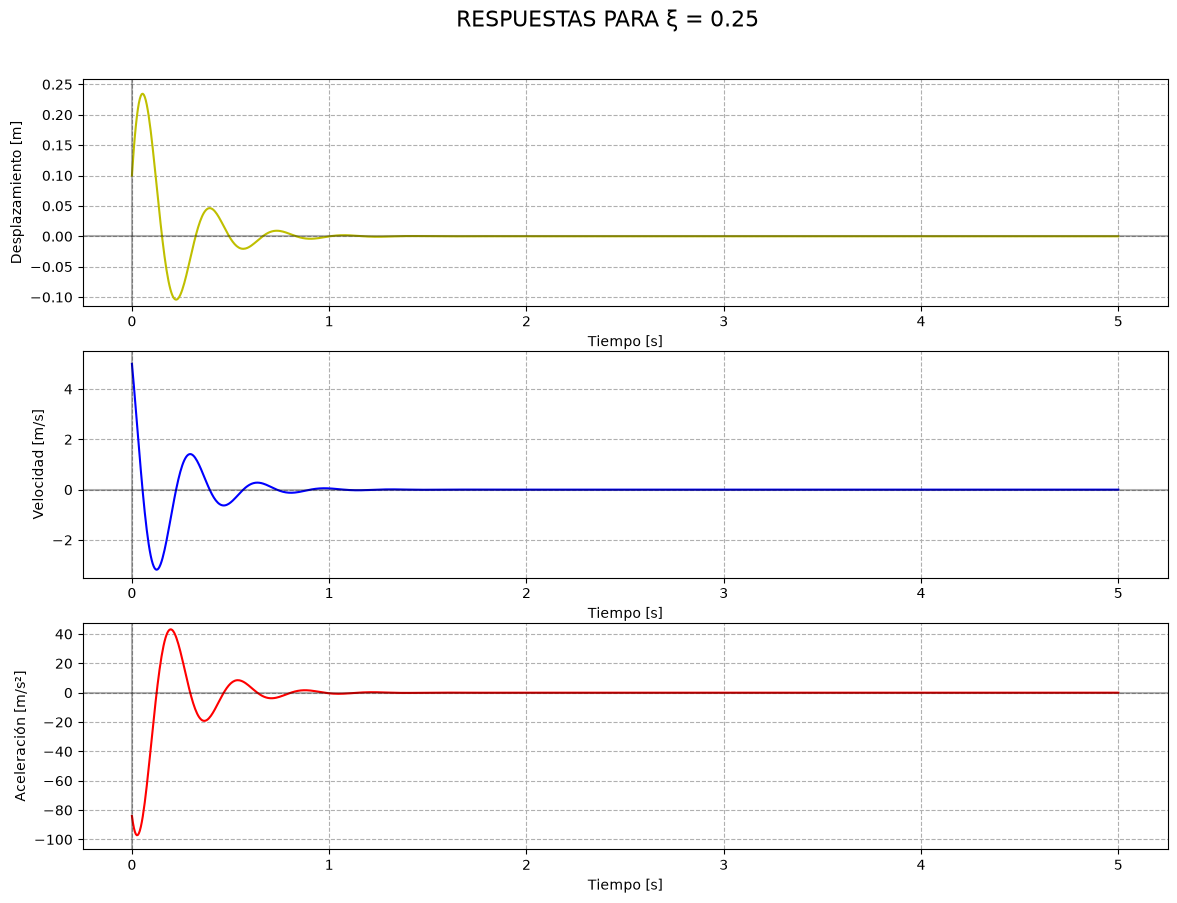

In [5]:
for xi in xi_valores:
    # Crear una figura con tres subplots para cada xi
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"RESPUESTAS PARA ξ = {xi}", fontsize=16, y=0.95)
    
    # Desplazamiento
    x = resultados[xi][0]
    x_min, x_max = np.min(x), np.max(x)
    ax1.plot(t, x, "y-", label="Desplazamiento")
    ax1.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax1.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax1.set_xlabel("Tiempo [s]")
    ax1.set_ylabel("Desplazamiento [m]")
    ax1.grid(True, linestyle="--")
    ax1.set_ylim(x_min - abs(x_min)*0.1, x_max + abs(x_max)*0.1)
    
    # Velocidad
    v = resultados[xi][1]
    v_min, v_max = np.min(v), np.max(v)
    ax2.plot(t, v, "b-", label="Velocidad")
    ax2.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax2.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax2.set_xlabel("Tiempo [s]")
    ax2.set_ylabel("Velocidad [m/s]")
    ax2.grid(True, linestyle="--")
    ax2.set_ylim(v_min - abs(v_min)*0.1, v_max + abs(v_max)*0.1)
    
    # Aceleración
    a = resultados[xi][2]
    a_min, a_max = np.min(a), np.max(a)
    ax3.plot(t, a, "r-", label="Aceleración")
    ax3.axhline(y=0, color="k", linestyle="-", alpha=0.3)
    ax3.axvline(x=0, color="k", linestyle="-", alpha=0.3)
    ax3.set_xlabel("Tiempo [s]")
    ax3.set_ylabel("Aceleración [m/s²]")
    ax3.grid(True, linestyle="--")
    ax3.set_ylim(a_min - abs(a_min)*0.1, a_max + abs(a_max)*0.1)
    
    plt.show()

### | *Comparación de resultados*

#### 1. *Gráficas de comparación:*

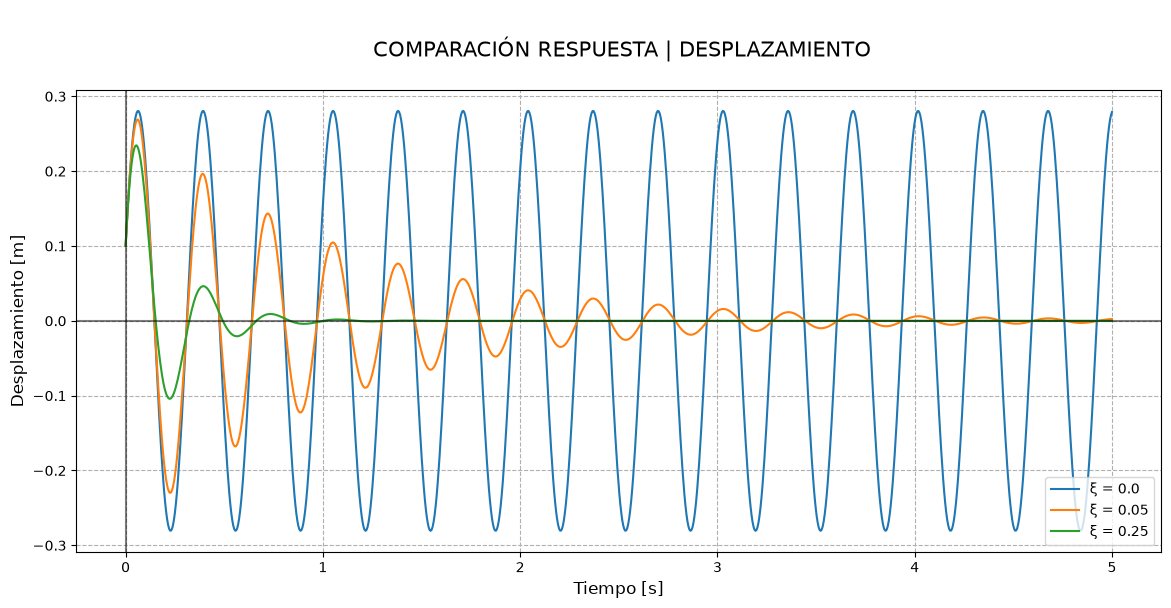

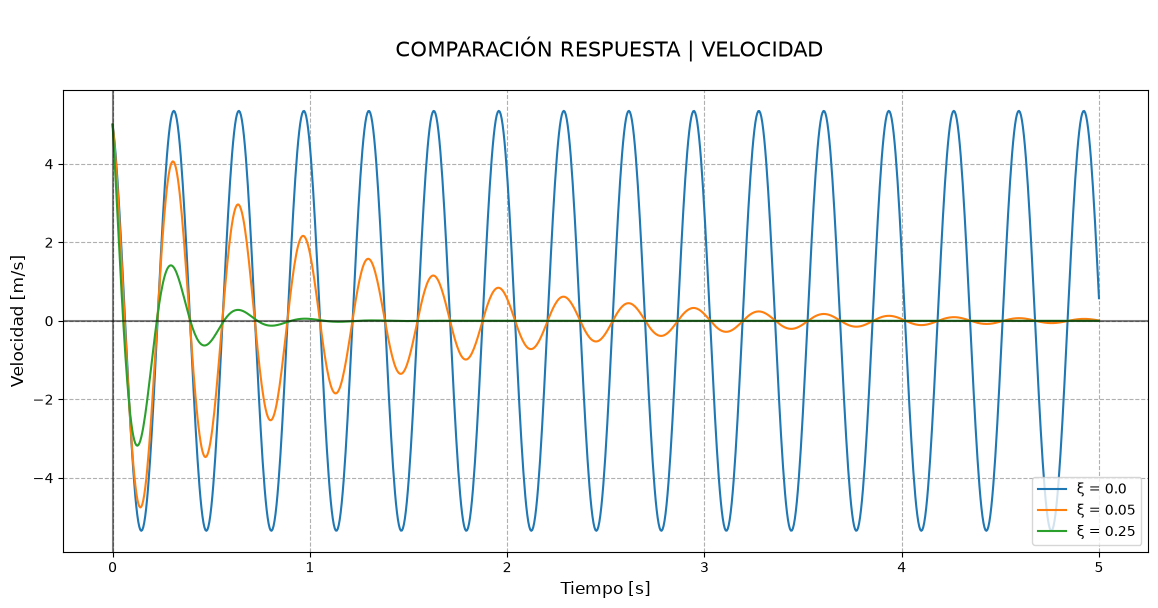

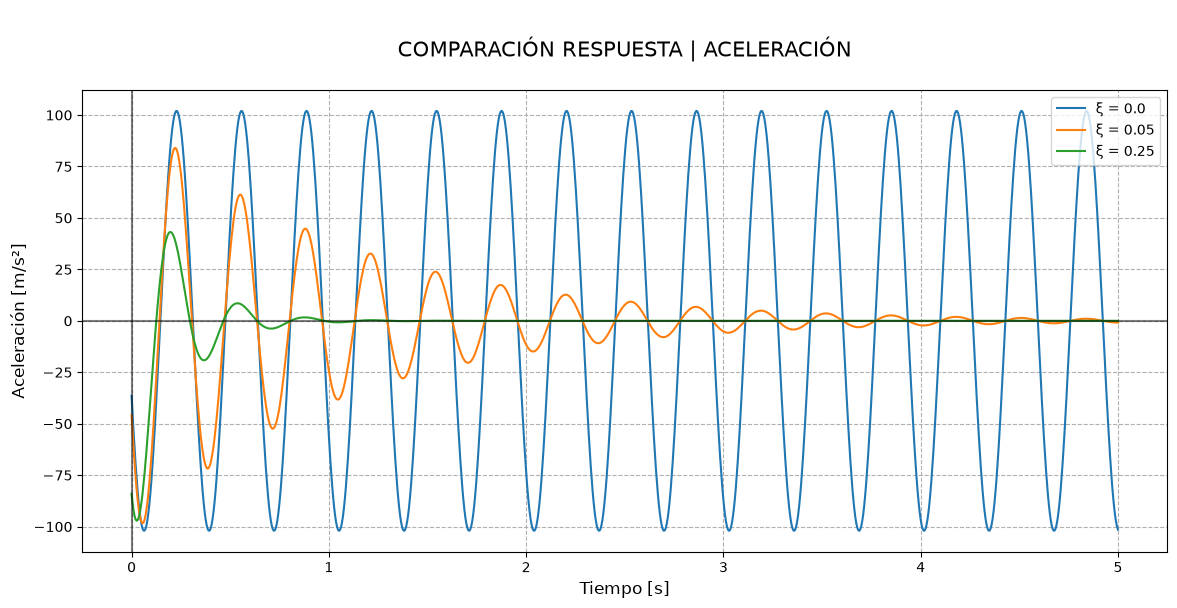

In [6]:
# Gráfica del Desplazamiento
plt.figure(figsize=(14, 6))

for xi in xi_valores:
    plt.plot(t, resultados[xi][0], label=f"ξ = {xi}")

# Configurar la gráfica
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Desplazamiento [m]", fontsize=12)
plt.title("\n COMPARACIÓN RESPUESTA | DESPLAZAMIENTO\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.show()

# Gráfica de la Velocidad
plt.figure(figsize=(14, 6))
for xi in xi_valores:
    plt.plot(t, resultados[xi][1], label=f"ξ = {xi}")

plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Velocidad [m/s]", fontsize=12)
plt.title("\n COMPARACIÓN RESPUESTA | VELOCIDAD\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.show()

# Gráfica de la Aceleración
plt.figure(figsize=(14, 6))
for xi in xi_valores:
    plt.plot(t, resultados[xi][2], label=f"ξ = {xi}")

plt.axhline(y=0, color="k", linestyle="-", alpha=0.5)
plt.axvline(x=0, color="k", linestyle="-", alpha=0.5)
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Aceleración [m/s²]", fontsize=12)
plt.title("\nCOMPARACIÓN RESPUESTA | ACELERACIÓN\n", fontsize=15)
plt.grid(True, linestyle="--")
plt.legend(fontsize=10)
plt.show()

#### 2. *Cálculo del tiempo en llegar al reposo y valores máximos:*

In [7]:
def encontrar_tiempo_reposo(t, x):
    """
    Encuentra el tiempo cuando la oscilación se mantiene dentro de ±2% del valor final (0 en este caso)
    """
    abs_x = np.abs(x)                       # Obtenemos el valor absoluto de x
    for i, val in enumerate(abs_x):
        if all(v <= 0.001 for v in abs_x[i:]):
            return t[i]
    return t[-1]

# Calcular resultados para cada valor de xi
resultados_comp = []
for xi in xi_valores:
    x, v, a = sistema_masa_resorte(xi, t)
    
    # Encontrar valores máximos
    x_max = np.max(np.abs(x))
    v_max = np.max(np.abs(v))
    a_max = np.max(np.abs(a))
    
    # Encontrar tiempo de reposo
    t_reposo = encontrar_tiempo_reposo(t, x)
    
    resultados_comp.append({
        "ξ": f"{xi:.3f}",
        "Desplazamiento Máximo [m]": f"{x_max:.3f}",
        "Velocidad Máxima [m/s]": f"{v_max:.3f}",
        "Aceleración Máxima [m/s²]": f"{a_max:.3f}",
        "Tiempo de Establecimiento [s]": f"{t_reposo:.3f}"
    })
    
df_resultados = pd.DataFrame(resultados_comp)

# Imprimir las tablas
print("\nTabla de Valores Máximos y Tiempo de Establecimiento")
print("="*100)
print(tabulate(df_resultados, headers="keys", tablefmt="fancy_grid", stralign="center", numalign="center", showindex=False))


Tabla de Valores Máximos y Tiempo de Establecimiento
╒══════╤═════════════════════════════╤══════════════════════════╤═════════════════════════════╤═════════════════════════════════╕
│  ξ   │  Desplazamiento Máximo [m]  │  Velocidad Máxima [m/s]  │  Aceleración Máxima [m/s²]  │  Tiempo de Establecimiento [s]  │
╞══════╪═════════════════════════════╪══════════════════════════╪═════════════════════════════╪═════════════════════════════════╡
│  0   │            0.281            │          5.351           │           102.045           │                5                │
├──────┼─────────────────────────────┼──────────────────────────┼─────────────────────────────┼─────────────────────────────────┤
│ 0.05 │            0.269            │            5             │           98.344            │                5                │
├──────┼─────────────────────────────┼──────────────────────────┼─────────────────────────────┼─────────────────────────────────┤
│ 0.25 │            0.234           

#### 3. *Cálculo de diferencias porcentuales entre casos:*

In [8]:
# Función para calcular diferencias porcentuales entre dos casos
def calcular_diferencias(caso1, caso2, xi1, xi2):
    diferencias = {}
    diferencias["ξ₁"] = f"{xi1:.3f}"
    diferencias["ξ₂"] = f"{xi2:.3f}"
    
    for columna in ["Desplazamiento Máximo [m]", "Velocidad Máxima [m/s]", "Aceleración Máxima [m/s²]"]:
        val1 = float(caso1[columna])
        val2 = float(caso2[columna])
        diff_porcentual = ((val2 - val1) / val1) * 100
        nombre_simple = columna.split("[")[0].strip()
        diferencias[f"Δ% en {nombre_simple}"] = f"{diff_porcentual:.1f}"
    
    return diferencias

# Calcular todas las comparaciones posibles
comparaciones = []
for i in range(len(xi_valores)):
    for j in range(i+1, len(xi_valores)):
        caso1 = df_resultados.iloc[i]
        caso2 = df_resultados.iloc[j]
        comparacion = calcular_diferencias(caso1, caso2, xi_valores[i], xi_valores[j])
        comparaciones.append(comparacion)

df_comparaciones = pd.DataFrame(comparaciones)

print("\nTabla de Diferencias Porcentuales entre Casos")
print("="*100)
print(tabulate(df_comparaciones, headers="keys", tablefmt="fancy_grid", stralign="center", numalign="center", showindex=False))

# Notas explicativas
print("\nNotas:")
print("- Δ% representa el cambio porcentual del segundo caso (ξ₂) respecto al primer caso (ξ₁)")
print("- Valores negativos indican una reducción en el segundo caso")
print("- El tiempo de establecimiento se define cuando la oscilación se mantiene dentro de ±2% del valor final")


Tabla de Diferencias Porcentuales entre Casos
╒══════╤══════╤═══════════════════════════════╤══════════════════════════╤════════════════════════════╕
│  ξ₁  │  ξ₂  │  Δ% en Desplazamiento Máximo  │  Δ% en Velocidad Máxima  │  Δ% en Aceleración Máxima  │
╞══════╪══════╪═══════════════════════════════╪══════════════════════════╪════════════════════════════╡
│  0   │ 0.05 │             -4.3              │           -6.6           │            -3.6            │
├──────┼──────┼───────────────────────────────┼──────────────────────────┼────────────────────────────┤
│  0   │ 0.25 │             -16.7             │           -6.6           │            -4.8            │
├──────┼──────┼───────────────────────────────┼──────────────────────────┼────────────────────────────┤
│ 0.05 │ 0.25 │              -13              │            0             │            -1.2            │
╘══════╧══════╧═══════════════════════════════╧══════════════════════════╧════════════════════════════╛

Notas:
- Δ% repr